# Лабораторная 7. Остаточные свёрточные сети. Дроп-аут. Батч-нормализация

**Задание.**

*1. Архитектура.* Реализовать свёрточную сеть с блоками слоёв с соединениями
напрямую (остаточными блоками). Использовать свёрточные блоки различной
архитектуры: 1) свёрточные блоки из предыдущего задания; 2) свёрточные блоки с
соединениями напрямую; 3) bottleneck-блоки (свёртки $1 \times 1$); и слои:
1) пакетной нормализации (batchnorm), 2) дроп-аута (dropout).

*2. Выборки.* Использовать выборку CIFAR-10 или др. (MNIST, FashionMNIST - для
сравнения). Для выбранного датасета подобрать параметры, при которых для
построенной архитектуры достигается наивысшее качество классификации. Сравнить с
результатами свёрточной сети (не остаточной) на тех же выборках.

*3. Гиперпараметры:* количество эпох; коэффициент обучения; количество скрытых
слоёв (количество остаточных блоков); количество каналов; параметры kernel,
stride, padding преобразований Conv2d и MaxPool2d; количество скрытых слоёв и
нейронов в многослойном перцептроне на выходе сети.

## 1. Теория

### Данные

Основная выборка FashionMNIST: изображения $28 \times 28$ в градациях серого,
10 классов одежды и обуви. MNIST используется для сравнения. Для перебора
гиперпараметров из обучающей части берутся 4000 изображений для обучения и 1500
отложенных для оценки. Сравнение с обычной сетью и финальная модель оцениваются
на тестовой выборке из 10000 изображений, которая в переборе не участвует;
финальная модель обучается на 12000 изображениях. Яркости делятся на 255 и
нормируются средним и стандартным отклонением обучающей части.

### Остаточный блок

Блок учит не искомое преобразование $H(x)$ целиком, а поправку к
тождественному:

$$y = F(x) + x, \qquad F(x) = H(x) - x .$$

При обратном распространении производная слагаемого $x$ равна единице, поэтому
градиент проходит через блок без затухания:

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I .$$

### Bottleneck-блок

Свёртки $1\times1$, $3\times3$ и $1\times1$ подряд: первая сжимает число
каналов, дорогая свёртка $3\times3$ выполняется в узком пространстве, последняя
расширяет каналы обратно. Свёртка $1\times1$ смешивает
только каналы и не смотрит на соседей по пространству.

### Виды блоков

- plain: две свёртки, как в блоке б) лабораторной 6, но без пуллинга:
  Conv-BN-ReLU-Conv-BN, затем ReLU;
- residual: тот же блок с соединением напрямую, $y = \mathrm{ReLU}(F(x) + x)$;
- bottleneck: свёртки $1\times1$, $k\times k$, $1\times1$ с соединением напрямую.

В блоках шаг 1 и дополнение $\lfloor k/2 \rfloor$, поэтому размер карты признаков
не меняется и $F(x)$ можно сложить с $x$. Размер уменьшают пуллинги $2\times2$ с
шагом 2 во входном слое и в переходе между двумя стадиями сети.

### Батч-нормализация

Каждый канал нормируется по мини-батчу:

$$\hat z = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}, \qquad
  y = \gamma\hat z + \beta,$$

где $\mu_B$ и $\sigma_B^2$ считаются по батчу, а $\gamma$, $\beta$ обучаются. На
инференсе вместо статистик батча используются накопленные скользящие средние.

### Дроп-аут

При обучении обнуляется случайная доля $p$ активаций с масштабированием
оставшихся, на инференсе пропускается всё. `Dropout2d` выключает канал целиком.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| тип блока | plain, residual, bottleneck |
| число блоков | 2, 4, 6, 8 |
| батч-нормализация | есть, нет |
| дроп-аут | $0$, $0.2$, $0.5$ |
| число каналов | 16, 24, 32 |
| коэффициент обучения | $0.01$, $0.05$, $0.1$ |
| размер ядра в блоках | 3, 5, 7 |
| выходной перцептрон | без скрытых слоёв, $(64)$, $(128)$, $(128, 64)$ |

Перебор последовательный: на каждом этапе фиксируются лучшие значения
предыдущих. Настраивается остаточная сеть, поэтому тип блока выбирается из
residual и bottleneck, а plain участвует в переборе для сравнения. Каждая
конфигурация обучается 8 эпох батчами по 64, финальная модель 12 эпох. В
таблицах обе точности взяты на эпохе с наибольшей accuracy на отложенной
выборке.

### Мера качества

Доля верных ответов accuracy, по классам precision, recall и $F_1$.

## 2. Данные

In [1]:
import os
import struct
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(20260905)
torch.backends.cudnn.deterministic = True  # одинаковые числа при перезапуске на GPU
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


FASHION_CLASSES = ['футболка', 'брюки', 'свитер', 'платье', 'пальто',
                   'сандалии', 'рубашка', 'кроссовки', 'сумка', 'ботинки']


def to_tensor(X, y, mean, std):
    """Изображения в тензор (N, 1, 28, 28) с нормировкой, метки в long."""
    t = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0  # ось 1 это канал
    t = (t - mean) / std
    # .to(DEVICE) переносит тензоры на видеокарту, если она есть
    return t.to(DEVICE), torch.tensor(y, dtype=torch.long).to(DEVICE)


def load(name, env, n_train, n_val, rng):
    """Обучающая и отложенная подвыборки из обучающей части и полные массивы."""
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte'); ytr = read_idx(D / 'train-labels-idx1-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte'); yte = read_idx(D / 't10k-labels-idx1-ubyte')
    perm = rng.permutation(len(Xtr))
    itr, ival = perm[:n_train], perm[n_train:n_train + n_val]  # части не пересекаются
    mean, std = Xtr.mean() / 255.0, Xtr.std() / 255.0
    return (to_tensor(Xtr[itr], ytr[itr], mean, std),
            to_tensor(Xtr[ival], ytr[ival], mean, std),
            (Xtr, ytr, Xte, yte, mean, std))


(Xf, yf), (Xfv, yfv), fashion_full = load('FashionMNIST', 'FASHION_DIR', 4000, 1500,
                                          np.random.default_rng(20260905))
(Xm, ym), (Xmv, ymv), mnist_full = load('MNIST', 'MNIST_DIR', 4000, 1500,
                                        np.random.default_rng(20260905))
print(f'FashionMNIST: обучающая {tuple(Xf.shape)}, отложенная {tuple(Xfv.shape)}')
print(f'MNIST:        обучающая {tuple(Xm.shape)}, отложенная {tuple(Xmv.shape)}')

FashionMNIST: обучающая (4000, 1, 28, 28), отложенная (1500, 1, 28, 28)
MNIST:        обучающая (4000, 1, 28, 28), отложенная (1500, 1, 28, 28)


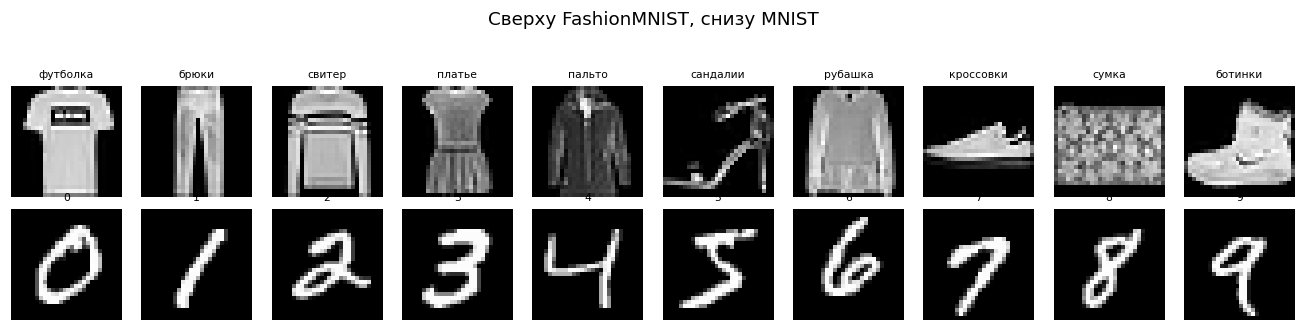

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
Xtr_raw, ytr_raw = fashion_full[0], fashion_full[1]
for c in range(10):
    j = np.flatnonzero(ytr_raw == c)[0]
    axes[0, c].imshow(Xtr_raw[j], cmap='gray'); axes[0, c].axis('off')
    axes[0, c].set_title(FASHION_CLASSES[c], fontsize=7)
Xm_raw, ym_raw = mnist_full[0], mnist_full[1]
for c in range(10):
    j = np.flatnonzero(ym_raw == c)[0]
    axes[1, c].imshow(Xm_raw[j], cmap='gray'); axes[1, c].axis('off')
    axes[1, c].set_title(str(c), fontsize=7)
fig.suptitle('Сверху FashionMNIST, снизу MNIST', y=1.06)
plt.tight_layout()
plt.show()

## 3. Блоки и сеть

In [4]:
def norm_layer(c, bn):
    """Батч-нормализация или пустышка, если нормализация выключена."""
    return nn.BatchNorm2d(c) if bn else nn.Identity()


class Block(nn.Module):
    """kind: plain - без соединения напрямую; residual - с соединением;
    bottleneck - свёртки 1x1 вокруг 3x3, с соединением."""

    def __init__(self, c, kind='plain', ks=3, bn=True, dropout=0.0):
        super().__init__()
        pad = ks // 2
        if kind == 'bottleneck':
            mid = max(4, c // 4)  # внутри блока число каналов сжимается вчетверо
            layers = [nn.Conv2d(c, mid, 1), norm_layer(mid, bn), nn.ReLU(),
                      nn.Conv2d(mid, mid, ks, 1, pad), norm_layer(mid, bn), nn.ReLU(),
                      nn.Conv2d(mid, c, 1)]
        else:
            layers = [nn.Conv2d(c, c, ks, 1, pad), norm_layer(c, bn), nn.ReLU(),
                      nn.Conv2d(c, c, ks, 1, pad)]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        layers.append(norm_layer(c, bn))  # нормализация стоит последней, до сложения
        self.body = nn.Sequential(*layers)
        self.kind = kind
        self.act = nn.ReLU()

    def forward(self, x):
        out = self.body(x)
        if self.kind in ('residual', 'bottleneck'):
            out = out + x  # соединение напрямую
        return self.act(out)


class Net(nn.Module):
    """Две стадии: стебель 28 на 14, блоки при C каналах, переход 14 на 7 с
    удвоением каналов, блоки при 2C, глобальный пуллинг и МСП."""

    def __init__(self, kind='plain', n_blocks=4, channels=16, ks=3,
                 bn=True, dropout=0.0, head=()):
        super().__init__()
        n1 = (n_blocks + 1) // 2  # блоки делятся между двумя стадиями поровну
        n2 = n_blocks - n1
        self.stem = nn.Sequential(nn.Conv2d(1, channels, 3, 1, 1), norm_layer(channels, bn),
                                  nn.ReLU(), nn.MaxPool2d(2, 2))
        # n1 блоков подряд; * раскрывает список блоков в аргументы Sequential
        self.stage1 = nn.Sequential(*[Block(channels, kind, ks, bn, dropout)
                                      for _ in range(n1)])
        self.transition = nn.Sequential(
            nn.Conv2d(channels, 2 * channels, 3, 1, 1), norm_layer(2 * channels, bn),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.stage2 = nn.Sequential(*[Block(2 * channels, kind, ks, bn, dropout)
                                      for _ in range(n2)])
        self.pool = nn.AdaptiveAvgPool2d(1)  # усреднение по всей карте признаков
        dims = [2 * channels] + list(head)
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], 10))
        self.head = nn.Sequential(*layers)

    def forward(self, x):
        z = self.stage2(self.transition(self.stage1(self.stem(x))))
        return self.head(self.pool(z).flatten(1))

In [5]:
def evaluate(model, X, y, batch=512):
    """Доля верных ответов, считается батчами."""
    model.eval()  # батч-нормализация и дроп-аут переходят в режим применения
    correct = 0
    with torch.no_grad():  # при оценке градиенты не нужны
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def run(model, Xtr, ytr, Xval, yval, lr, epochs, batch=64, seed=0):
    """Обучение с записью accuracy на обучающей выборке и на Xval после каждой эпохи."""
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    lossf = nn.CrossEntropyLoss()
    train_hist, val_hist = [], []
    for _ in range(epochs):
        model.train()  # режим обучения: статистики батча и случайное обнуление
        perm = torch.randperm(len(Xtr), device=Xtr.device)  # новый порядок объектов
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()  # обнуление градиентов прошлого шага
            lossf(model(Xtr[b]), ytr[b]).backward()  # градиенты функции потерь по весам
            opt.step()  # шаг оптимизатора
        val_hist.append(evaluate(model, Xval, yval))
        train_hist.append(evaluate(model, Xtr, ytr))
    return np.array(train_hist), np.array(val_hist)


def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 4. Главный эксперимент: глубина и тип блока

In [6]:
EPOCHS = 8
rows = []
# itertools.product перебирает все пары: тип блока и число блоков
for kind, n_blocks in itertools.product(['plain', 'residual', 'bottleneck'], [2, 4, 6, 8]):
    torch.manual_seed(20260905)
    model = Net(kind=kind, n_blocks=n_blocks, channels=24).to(DEVICE)  # веса на видеокарту
    tr, va = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    # обе точности берутся на эпохе с лучшей accuracy на отложенной
    rows.append(dict(stage='глубина', dataset='FashionMNIST', kind=kind, n_blocks=n_blocks,
                     channels=24, ks=3, bn=True, dropout=0.0, lr=0.05, head='()',
                     train_acc=float(tr[va.argmax()]), val_acc=float(va.max()),
                     params=n_params(model), curve=list(np.round(va, 4))))
depth = pd.DataFrame(rows)
print(depth.pivot_table(index='n_blocks', columns='kind',
                        values=['train_acc', 'val_acc']).round(4).to_string())

          train_acc                     val_acc                 
kind     bottleneck   plain residual bottleneck   plain residual
n_blocks                                                        
2            0.8398  0.8760   0.8645     0.8233  0.8393   0.8413
4            0.8472  0.8825   0.8300     0.8280  0.8487   0.8167
6            0.8138  0.8550   0.8528     0.7953  0.8327   0.8327
8            0.8545  0.8460   0.8592     0.8140  0.8333   0.8480


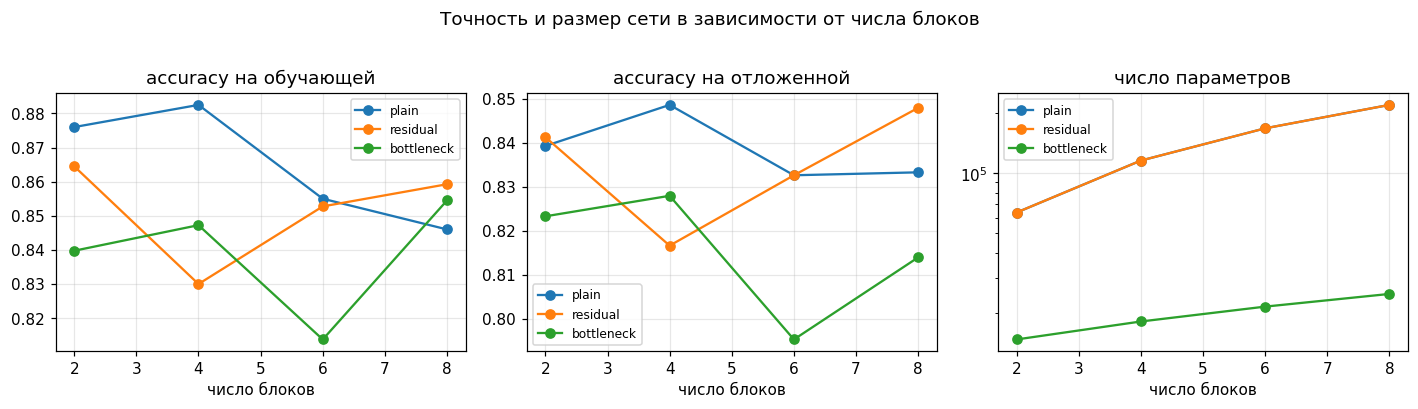

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    s = depth[depth.kind == kind].sort_values('n_blocks')
    axes[0].plot(s.n_blocks, s.train_acc, marker='o', label=kind)
    axes[1].plot(s.n_blocks, s.val_acc, marker='o', label=kind)
    axes[2].plot(s.n_blocks, s.params, marker='o', label=kind)
axes[0].set_title('accuracy на обучающей'); axes[1].set_title('accuracy на отложенной')
axes[2].set_title('число параметров'); axes[2].set_yscale('log')
for ax in axes:
    ax.set_xlabel('число блоков'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Точность и размер сети в зависимости от числа блоков', y=1.02)
plt.tight_layout()
plt.show()

## 5. Батч-нормализация и дроп-аут

In [8]:
# выбор только среди блоков с соединением напрямую
best_depth = depth[depth.kind != 'plain'].sort_values('val_acc', ascending=False).iloc[0]
KIND, NB = best_depth['kind'], int(best_depth['n_blocks'])
print(f'лучшая пара: {KIND}, блоков {NB}, accuracy {best_depth["val_acc"]:.4f}')

rows = []
for bn, dp in itertools.product([True, False], [0.0, 0.2, 0.5]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=24, bn=bn, dropout=dp).to(DEVICE)
    tr, va = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    rows.append(dict(stage='bn и dropout', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=24, ks=3, bn=bn, dropout=dp, lr=0.05, head='()',
                     train_acc=float(tr[va.argmax()]), val_acc=float(va.max()),
                     params=n_params(model), curve=list(np.round(va, 4))))
regu = pd.DataFrame(rows)
regu['разрыв'] = regu.train_acc - regu.val_acc
print(regu[['bn', 'dropout', 'train_acc', 'val_acc', 'разрыв']].round(4).to_string(index=False))

лучшая пара: residual, блоков 8, accuracy 0.8480


   bn  dropout  train_acc  val_acc  разрыв
 True      0.0     0.8592   0.8480  0.0112
 True      0.2     0.8485   0.8227  0.0258
 True      0.5     0.8280   0.8167  0.0113
False      0.0     0.8252   0.8180  0.0073
False      0.2     0.8320   0.8240  0.0080
False      0.5     0.8075   0.8020  0.0055


## 6. Каналы, коэффициент обучения, размер ядра и выходной перцептрон

In [9]:
best_regu = regu.sort_values('val_acc', ascending=False).iloc[0]
BN, DP = bool(best_regu['bn']), float(best_regu['dropout'])
print(f'выбраны batchnorm={BN}, dropout={DP}')

rows = []
for ch, lr in itertools.product([16, 24, 32], [0.01, 0.05, 0.1]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=ch, bn=BN, dropout=DP).to(DEVICE)
    tr, va = run(model, Xf, yf, Xfv, yfv, lr=lr, epochs=EPOCHS)
    rows.append(dict(stage='каналы и lr', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=ch, ks=3, bn=BN, dropout=DP, lr=lr, head='()',
                     train_acc=float(tr[va.argmax()]), val_acc=float(va.max()),
                     params=n_params(model), curve=list(np.round(va, 4))))
chan = pd.DataFrame(rows)
print(chan.pivot_table(index='channels', columns='lr', values='val_acc').round(4).to_string())

выбраны batchnorm=True, dropout=0.0


lr          0.01    0.05    0.10
channels                        
16        0.8387  0.8387  0.8300
24        0.8447  0.8480  0.8173
32        0.8533  0.8660  0.8300


In [10]:
best_ch = chan.sort_values('val_acc', ascending=False).iloc[0]
CH, LR = int(best_ch['channels']), float(best_ch['lr'])
print(f'выбраны каналов {CH}, lr {LR}')

rows = []
for ks in [3, 5, 7]:
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=CH, ks=ks, bn=BN, dropout=DP).to(DEVICE)
    tr, va = run(model, Xf, yf, Xfv, yfv, lr=LR, epochs=EPOCHS)
    rows.append(dict(stage='ядро', dataset='FashionMNIST', kind=KIND, n_blocks=NB,
                     channels=CH, ks=ks, bn=BN, dropout=DP, lr=LR, head='()',
                     train_acc=float(tr[va.argmax()]), val_acc=float(va.max()),
                     params=n_params(model), curve=list(np.round(va, 4))))
kern = pd.DataFrame(rows)
print(kern[['ks', 'train_acc', 'val_acc', 'params']].round(4).to_string(index=False))

выбраны каналов 32, lr 0.05


 ks  train_acc  val_acc  params
  3     0.8942   0.8660  390602
  5     0.8718   0.8460 1045962
  7     0.8370   0.8147 2029002


In [11]:
KS = int(kern.sort_values('val_acc', ascending=False).iloc[0]['ks'])
print(f'выбран размер ядра {KS}')

HEAD_OPTIONS = [(), (64,), (128,), (128, 64)]
HEAD_BY_NAME = {str(h): h for h in HEAD_OPTIONS}  # чтобы вернуть кортеж по строке из таблицы

rows = []
for head in HEAD_OPTIONS:
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=CH, ks=KS, bn=BN, dropout=DP,
                head=head).to(DEVICE)
    tr, va = run(model, Xf, yf, Xfv, yfv, lr=LR, epochs=EPOCHS)
    rows.append(dict(stage='голова', dataset='FashionMNIST', kind=KIND, n_blocks=NB,
                     channels=CH, ks=KS, bn=BN, dropout=DP, lr=LR, head=str(head),
                     train_acc=float(tr[va.argmax()]), val_acc=float(va.max()),
                     params=n_params(model), curve=list(np.round(va, 4))))
heads = pd.DataFrame(rows)
print(heads[['head', 'train_acc', 'val_acc', 'params']].round(4).to_string(index=False))
HEAD = HEAD_BY_NAME[heads.sort_values('val_acc', ascending=False).iloc[0]['head']]

выбран размер ядра 3


     head  train_acc  val_acc  params
       ()     0.8942    0.866  390602
    (64,)     0.8312    0.820  394762
   (128,)     0.8560    0.846  399562
(128, 64)     0.7845    0.782  407178


## 7. Сравнение остаточной и обычной сети на обеих выборках

In [12]:
print('выбранная конфигурация:')
print(f'  блок {KIND}, блоков {NB}, каналов {CH}, ядро {KS}, batchnorm {BN}, '
      f'dropout {DP}, lr {LR}, скрытые слои выходного перцептрона {HEAD}')

_, _, Xte_f, yte_f, mean_f, std_f = fashion_full
_, _, Xte_m, yte_m, mean_m, std_m = mnist_full
Xft, yft = to_tensor(Xte_f, yte_f, mean_f, std_f)
Xmt, ymt = to_tensor(Xte_m, yte_m, mean_m, std_m)

rows = []
for ds, (Xa, ya, Xtest, ytest) in [('FashionMNIST', (Xf, yf, Xft, yft)),
                                   ('MNIST', (Xm, ym, Xmt, ymt))]:
    for kind in ['plain', KIND]:
        torch.manual_seed(20260905)
        model = Net(kind=kind, n_blocks=NB, channels=CH, ks=KS, bn=BN, dropout=DP,
                    head=HEAD).to(DEVICE)
        tr, te = run(model, Xa, ya, Xtest, ytest, lr=LR, epochs=EPOCHS)
        rows.append(dict(dataset=ds, kind=kind, train_acc=float(tr[-1]),
                         test_acc=float(te[-1]), params=n_params(model)))
cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))

выбранная конфигурация:
  блок residual, блоков 8, каналов 32, ядро 3, batchnorm True, dropout 0.0, lr 0.05, скрытые слои выходного перцептрона ()


     dataset     kind  train_acc  test_acc  params
FashionMNIST    plain     0.8198    0.7886  390602
FashionMNIST residual     0.8942    0.8527  390602
       MNIST    plain     0.9820    0.9671  390602
       MNIST residual     0.9495    0.9360  390602


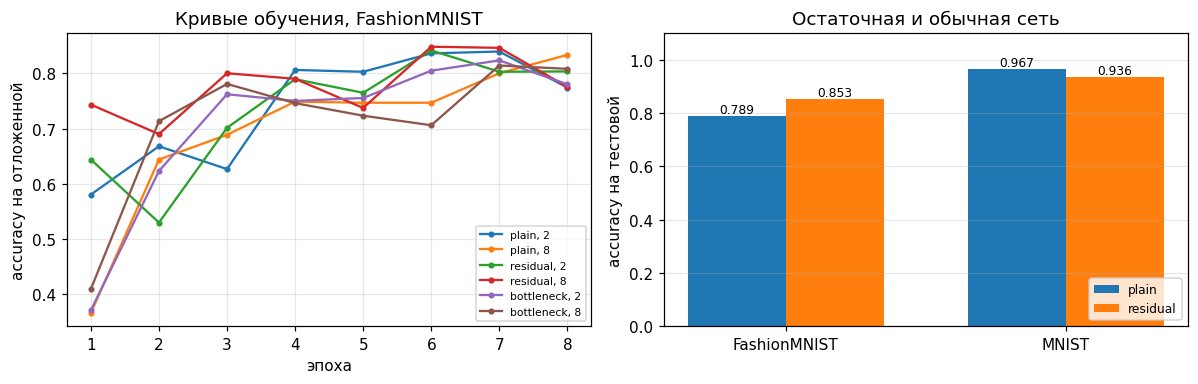

In [13]:
allres = pd.concat([depth, regu.drop(columns='разрыв'), chan, kern, heads], ignore_index=True)
allres.drop(columns='curve').to_csv('results.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    for n_blocks in [2, 8]:
        s = depth[(depth.kind == kind) & (depth.n_blocks == n_blocks)]
        axes[0].plot(range(1, EPOCHS + 1), s.iloc[0]['curve'],
                     marker='o', ms=3, label=f'{kind}, {n_blocks}')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на отложенной')
axes[0].set_title('Кривые обучения, FashionMNIST'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)

xs = np.arange(2)
w = 0.35
for i, kind in enumerate(['plain', KIND]):
    s = cmp[cmp.kind == kind]
    bars = axes[1].bar(xs + (i - 0.5) * w, s.test_acc.values, w, label=kind)
    axes[1].bar_label(bars, fmt='%.3f', fontsize=8)  # значение над каждым столбцом
axes[1].set_xticks(xs); axes[1].set_xticklabels(['FashionMNIST', 'MNIST'])
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('accuracy на тестовой')
axes[1].set_title('Остаточная и обычная сеть'); axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Финальная модель на выборке большего размера

In [14]:
Xtr_raw, ytr_raw, _, _, mean, std = fashion_full
idx = RNG.choice(len(Xtr_raw), 12000, replace=False)
Xb, yb = to_tensor(Xtr_raw[idx], ytr_raw[idx], mean, std)

torch.manual_seed(20260905)
final = Net(kind=KIND, n_blocks=NB, channels=CH, ks=KS, bn=BN, dropout=DP,
            head=HEAD).to(DEVICE)
tr_h, te_h = run(final, Xb, yb, Xft, yft, lr=LR, epochs=12)
print(f'accuracy на тестовой выборке FashionMNIST (10000) после 12 эпох: {te_h[-1]:.4f}')
print(f'число параметров: {n_params(final):,}')

accuracy на тестовой выборке FashionMNIST (10000) после 12 эпох: 0.8914
число параметров: 390,602


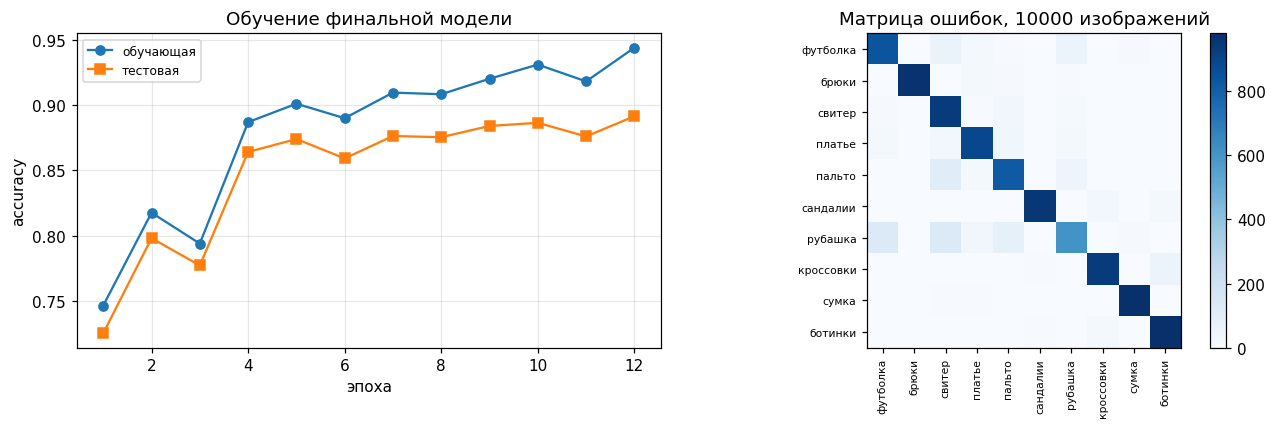

              precision    recall  f1-score   support

    футболка      0.841     0.843     0.842      1000
       брюки      0.992     0.968     0.980      1000
      свитер      0.732     0.937     0.822      1000
      платье      0.899     0.890     0.894      1000
      пальто      0.829     0.822     0.825      1000
    сандалии      0.991     0.953     0.971      1000
     рубашка      0.804     0.608     0.692      1000
   кроссовки      0.954     0.936     0.945      1000
       сумка      0.976     0.981     0.979      1000
     ботинки      0.924     0.976     0.949      1000

    accuracy                          0.891     10000
   macro avg      0.894     0.891     0.890     10000
weighted avg      0.894     0.891     0.890     10000



In [15]:
final.eval()
with torch.no_grad():  # без подсчёта градиентов, батчами по 512
    pred = torch.cat([final(Xft[s:s + 512]).argmax(1) for s in range(0, len(Xft), 512)])
pred = pred.cpu().numpy()  # .cpu() забирает тензор с видеокарты

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 13), tr_h, marker='o', label='обучающая')
axes[0].plot(range(1, 13), te_h, marker='s', label='тестовая')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

cm = confusion_matrix(yte_f, pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xticklabels(FASHION_CLASSES, rotation=90, fontsize=7)
axes[1].set_yticklabels(FASHION_CLASSES, fontsize=7)
axes[1].set_title('Матрица ошибок, 10000 изображений')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(classification_report(yte_f, pred, target_names=FASHION_CLASSES, digits=3))